# Cross Dataset Generalization Analysis
How well do YOLOv11s and Faster R-CNN generalise to unseen adverse-weather datasets?

Analyses the generalisation capability of the trained models.

Contents:


*   Cross-dataset comparison.
*   Performance degradation analysis.
*   Seed stability analysis.
*   Statistical summaries.

# Mount drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports & Paths

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Project directories
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation"
)

RUNS_DIR = PROJECT_DIR / "Runs"
RESULTS_DIR = PROJECT_DIR / "Results"

OUTPUT_DIR = RESULTS_DIR / "crossdataset_generalization_analysis"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not RUNS_DIR.exists():
    raise FileNotFoundError(
        f"Runs directory not found: {RUNS_DIR}"
    )

print("Runs directory:", RUNS_DIR)
print("Output directory:", OUTPUT_DIR)

Runs directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs
Output directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis


# Inspect available CSV files

In [ ]:
all_csv_files = sorted(RUNS_DIR.rglob("*.csv"))

print("Total CSV files:", len(all_csv_files))

for file_path in all_csv_files:
    print(file_path.relative_to(RUNS_DIR))


Total CSV files: 35
comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv
comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv
faster_rcnn/acdc_in_domain_faster_rcnn_seed123/acdc_faster_rcnn_in_domain_results_summary.csv
faster_rcnn/acdc_in_domain_faster_rcnn_seed42/acdc_faster_rcnn_in_domain_results_summary.csv
faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/dawn_to_acdc_faster_rcnn_seed123_results_summary.csv
faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/dawn_to_acdc_faster_rcnn_seed42_results_summary.csv
faster_rcnn/acdc_to_dawn_faster_rcnn_seed456/dawn_to_acdc_faster_rcnn_seed456_results_summary.csv
faster_rcnn/dawn_in_domain_faster_rcnn_seed123/dawn_faster_rcnn_in_domain_seed123_results_summary.csv
faster_rcnn/dawn_in_domain_faster_rcnn_seed456/dawn_faster_rcnn_in_domain_seed456_results_summary.csv
faster_rcnn/dawn_indomain_fasterrcnn_r50fpn_seed42/dawn_faster_rcnn_in_domain_seed4

# Select evaluation files

In [ ]:
def select_evaluation_files(runs_directory: Path):
    selected_files = []

    for file_path in sorted(runs_directory.rglob("*.csv")):
        name = file_path.name.lower()
        path_text = str(file_path).lower().replace("\\", "/")

        # Ultralytics training history, not final evaluation results
        if name == "results.csv":
            continue

        # Previously generated comparison/analysis tables
        if "comparison" in path_text or "comparisons" in path_text:
            continue

        # Keep every other CSV.
        # Files without recognised evaluation metrics will automatically
        # be rejected later by load_all_result_summaries().
        selected_files.append(file_path)

    return selected_files


evaluation_files = select_evaluation_files(RUNS_DIR)

print("Selected evaluation files:", len(evaluation_files))
for file_path in evaluation_files:
    print(file_path.relative_to(RUNS_DIR))


Selected evaluation files: 26
faster_rcnn/acdc_in_domain_faster_rcnn_seed123/acdc_faster_rcnn_in_domain_results_summary.csv
faster_rcnn/acdc_in_domain_faster_rcnn_seed42/acdc_faster_rcnn_in_domain_results_summary.csv
faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/dawn_to_acdc_faster_rcnn_seed123_results_summary.csv
faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/dawn_to_acdc_faster_rcnn_seed42_results_summary.csv
faster_rcnn/acdc_to_dawn_faster_rcnn_seed456/dawn_to_acdc_faster_rcnn_seed456_results_summary.csv
faster_rcnn/dawn_in_domain_faster_rcnn_seed123/dawn_faster_rcnn_in_domain_seed123_results_summary.csv
faster_rcnn/dawn_in_domain_faster_rcnn_seed456/dawn_faster_rcnn_in_domain_seed456_results_summary.csv
faster_rcnn/dawn_indomain_fasterrcnn_r50fpn_seed42/dawn_faster_rcnn_in_domain_seed42_results_summary.csv
faster_rcnn/dawn_to_acdc_faster_rcnn_seed123/dawn_to_acdc_faster_rcnn_seed123_results_summary.csv
faster_rcnn/dawn_to_acdc_faster_rcnn_seed42/dawn_to_acdc_faster_rcnn_seed42_results_

# Helper functions

In [ ]:
STANDARD_COLUMNS = [
    "experiment",
    "dataset",
    "source_train_dataset",
    "target_test_dataset",
    "transfer_direction",
    "model",
    "seed",
    "condition",
    "mAP50-95",
    "mAP50",
    "mAP75",
    "Precision",
    "Recall",
    "F1-score",
    "Preprocess_ms_per_image",
    "Inference_ms_per_image",
    "Postprocess_ms_per_image",
    "FPS",
    "source_file",
]


def normalise_column_name(column):
    text = str(column).strip().lower()
    text = text.replace(" ", "_")
    text = text.replace("-", "_")
    text = text.replace("/", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


COLUMN_ALIASES = {
    "weather": "condition",
    "split": "condition",
    "evaluation_condition": "condition",

    "map50_95": "mAP50-95",
    "map_50_95": "mAP50-95",
    "map5095": "mAP50-95",
    "map": "mAP50-95",
    "box_map": "mAP50-95",

    "map50": "mAP50",
    "map_50": "mAP50",
    "box_map50": "mAP50",

    "map75": "mAP75",
    "map_75": "mAP75",
    "box_map75": "mAP75",

    "precision": "Precision",
    "precision_b": "Precision",
    "metrics_precision_b": "Precision",

    "recall": "Recall",
    "recall_b": "Recall",
    "metrics_recall_b": "Recall",

    "f1": "F1-score",
    "f1_score": "F1-score",
    "f1score": "F1-score",

    "preprocess_ms": "Preprocess_ms_per_image",
    "preprocess_ms_per_image": "Preprocess_ms_per_image",

    "inference_ms": "Inference_ms_per_image",
    "inference_ms_per_image": "Inference_ms_per_image",

    "postprocess_ms": "Postprocess_ms_per_image",
    "postprocess_ms_per_image": "Postprocess_ms_per_image",

    "fps": "FPS",
}


def extract_seed(path_text):
    match = re.search(r"seed[_\-]?(\d+)", path_text.lower())
    return int(match.group(1)) if match else pd.NA


def infer_model(path_text):
    text = path_text.lower()
    if "faster" in text or "faster_rcnn" in text:
        return "Faster R-CNN"
    if "yolo" in text:
        return "YOLOv11s"
    return pd.NA


def infer_experiment_and_direction(path_text):
    text = path_text.lower().replace("\\\\", "/")

    # Use folder/path direction, not only the CSV filename.
    if "acdc_to_dawn" in text:
        return "acdc_>dawn", "ACDC", "DAWN", "ACDC → DAWN"

    if "dawn_to_acdc" in text:
        return "dawn_>acdc", "DAWN", "ACDC", "DAWN → ACDC"

    if "in_domain" in text or "indomain" in text:
        if "acdc" in text:
            return "in_domain", "ACDC", "ACDC", "ACDC in-domain"
        if "dawn" in text:
            return "in_domain", "DAWN", "DAWN", "DAWN in-domain"

    return pd.NA, pd.NA, pd.NA, pd.NA


def infer_dataset(path_text):
    text = path_text.lower()
    experiment, source, target, direction = infer_experiment_and_direction(text)

    if experiment == "in_domain":
        return source

    if experiment in {"acdc_>dawn", "dawn_>acdc"}:
        return target

    if "acdc" in text and "dawn" not in text:
        return "ACDC"
    if "dawn" in text and "acdc" not in text:
        return "DAWN"

    return pd.NA


def clean_condition(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()

    mapping = {
        "all": "global",
        "overall": "global",
        "total": "global",
        "test": "global",
        "global": "global",
        "fog": "fog",
        "foggy": "fog",
        "rain": "rain",
        "rainy": "rain",
        "snow": "snow",
        "snowy": "snow",
    }

    return mapping.get(text, text)


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def compute_f1(precision, recall):
    denominator = precision + recall
    return np.where(
        denominator > 0,
        2 * precision * recall / denominator,
        np.nan,
    )


#  Read standard and legacy summary formats

In [ ]:
def convert_legacy_weather_summary(df, file_path):
    """
    Converts a legacy table where:
    - rows are metrics;
    - columns are global/fog/rain/snow.
    """

    working = df.copy()

    if working.empty:
        return None

    first_column = working.columns[0]
    metric_values = working[first_column].astype(str).str.lower()

    recognised_metrics = metric_values.str.contains(
        r"map|precision|recall|f1",
        regex=True,
        na=False,
    )

    weather_columns = [
        column for column in working.columns
        if str(column).strip().lower() in {"global", "fog", "rain", "snow"}
    ]

    if recognised_metrics.sum() == 0 or len(weather_columns) == 0:
        return None

    records = []

    metric_mapping = {
        "map50": "mAP50",
        "map50-95": "mAP50-95",
        "map50_95": "mAP50-95",
        "map75": "mAP75",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1-score",
        "f1-score": "F1-score",
        "f1_score": "F1-score",
    }

    for condition_column in weather_columns:
        record = {"condition": clean_condition(condition_column)}

        for _, row in working.iterrows():
            raw_metric = str(row[first_column]).strip().lower().replace(" ", "")
            standard_metric = metric_mapping.get(raw_metric)

            if standard_metric is not None:
                record[standard_metric] = row[condition_column]

        records.append(record)

    return pd.DataFrame(records)


def standardise_loaded_dataframe(df, file_path):
    path_text = str(file_path)

    experiment, source_dataset, target_dataset, transfer_direction = (
        infer_experiment_and_direction(path_text)
    )

    model = infer_model(path_text)
    seed = extract_seed(path_text)
    dataset = infer_dataset(path_text)

    working = df.copy()
    working.columns = [normalise_column_name(column) for column in working.columns]

    rename_mapping = {}
    for column in working.columns:
        if column in COLUMN_ALIASES:
            rename_mapping[column] = COLUMN_ALIASES[column]

    working = working.rename(columns=rename_mapping)

    # Try legacy conversion when there is no condition column.
    if "condition" not in working.columns:
        raw_again = pd.read_csv(file_path)
        legacy_df = convert_legacy_weather_summary(raw_again, file_path)

        if legacy_df is not None:
            working = legacy_df

    # Some summary files may store metric names vertically.
    if "condition" not in working.columns and working.shape[1] >= 2:
        first_column = working.columns[0]
        first_values = working[first_column].astype(str).str.lower()

        if first_values.str.contains(r"map|precision|recall|f1", regex=True).any():
            legacy_df = convert_legacy_weather_summary(
                pd.read_csv(file_path),
                file_path,
            )
            if legacy_df is not None:
                working = legacy_df

    # If a single-row global summary has no condition.
    if "condition" not in working.columns:
        working["condition"] = "global"

    working["condition"] = working["condition"].map(clean_condition)

    # Metadata inferred primarily from the folder path.
    working["experiment"] = experiment
    working["dataset"] = dataset
    working["source_train_dataset"] = source_dataset
    working["target_test_dataset"] = target_dataset
    working["transfer_direction"] = transfer_direction
    working["model"] = model
    working["seed"] = seed
    working["source_file"] = str(file_path.relative_to(RUNS_DIR))

    # Add missing expected columns.
    for column in STANDARD_COLUMNS:
        if column not in working.columns:
            working[column] = pd.NA

    numeric_columns = [
        "seed",
        "mAP50-95",
        "mAP50",
        "mAP75",
        "Precision",
        "Recall",
        "F1-score",
        "Preprocess_ms_per_image",
        "Inference_ms_per_image",
        "Postprocess_ms_per_image",
        "FPS",
    ]

    for column in numeric_columns:
        working[column] = safe_numeric(working[column])

    # Compute F1 where absent.
    missing_f1 = working["F1-score"].isna()
    working.loc[missing_f1, "F1-score"] = compute_f1(
        working.loc[missing_f1, "Precision"],
        working.loc[missing_f1, "Recall"],
    )

    # Compute FPS from inference time where absent.
    missing_fps = (
        working["FPS"].isna()
        & working["Inference_ms_per_image"].notna()
        & (working["Inference_ms_per_image"] > 0)
    )
    working.loc[missing_fps, "FPS"] = (
        1000 / working.loc[missing_fps, "Inference_ms_per_image"]
    )

    # Compute inference time from FPS where absent.
    missing_inference = (
        working["Inference_ms_per_image"].isna()
        & working["FPS"].notna()
        & (working["FPS"] > 0)
    )
    working.loc[missing_inference, "Inference_ms_per_image"] = (
        1000 / working.loc[missing_inference, "FPS"]
    )

    return working[STANDARD_COLUMNS]


def load_all_result_summaries(evaluation_file_paths):
    loaded_frames = []
    ignored_records = []

    for file_path in evaluation_file_paths:
        try:
            raw_df = pd.read_csv(file_path)
            standard_df = standardise_loaded_dataframe(raw_df, file_path)

            useful_metric_count = standard_df[
                [
                    "mAP50-95",
                    "mAP50",
                    "mAP75",
                    "Precision",
                    "Recall",
                    "F1-score",
                    "FPS",
                ]
            ].notna().sum().sum()

            if useful_metric_count == 0:
                ignored_records.append({
                    "source_file": str(file_path.relative_to(RUNS_DIR)),
                    "reason": "No recognised evaluation metrics",
                })
                continue

            loaded_frames.append(standard_df)

        except Exception as error:
            ignored_records.append({
                "source_file": str(file_path.relative_to(RUNS_DIR)),
                "reason": repr(error),
            })

    if loaded_frames:
        combined_df = pd.concat(loaded_frames, ignore_index=True)
    else:
        combined_df = pd.DataFrame(columns=STANDARD_COLUMNS)

    ignored_df = pd.DataFrame(ignored_records)

    return combined_df, ignored_df


# Load all evaluation results

In [ ]:
results_df, ignored_files_df = load_all_result_summaries(evaluation_files)

print("Loaded rows:", len(results_df))
print("Ignored files:", len(ignored_files_df))

display(results_df.head(20))

if not ignored_files_df.empty:
    display(ignored_files_df)


Loaded rows: 84
Ignored files: 2


,experiment,dataset,source_train_dataset,target_test_dataset,transfer_direction,model,seed,condition,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,Preprocess_ms_per_image,Inference_ms_per_image,Postprocess_ms_per_image,FPS,source_file
0,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,global,0.4283,0.6121,0.4556,NaN,NaN,NaN,NaN,61.7702,NaN,16.1890,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
1,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,fog,0.5722,0.7643,0.6215,NaN,NaN,NaN,NaN,61.7869,NaN,16.1847,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
2,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,rain,0.3745,0.5446,0.3881,NaN,NaN,NaN,NaN,60.9978,NaN,16.3940,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
3,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,snow,0.5154,0.6973,0.5677,NaN,NaN,NaN,NaN,61.9047,NaN,16.1539,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
4,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,42,global,0.4128,0.5963,0.4499,NaN,NaN,NaN,NaN,62.1002,NaN,16.1030,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...
5,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,42,fog,0.5472,0.7540,0.5907,NaN,NaN,NaN,NaN,61.8578,NaN,16.1661,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...
6,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,42,rain,0.3631,0.5262,0.3973,NaN,NaN,NaN,NaN,61.8912,NaN,16.1574,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...
7,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,42,snow,0.4889,0.6951,0.5272,NaN,NaN,NaN,NaN,61.8987,NaN,16.1554,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...
8,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,123,global,0.2546,0.3772,0.2769,NaN,NaN,NaN,NaN,46.6910,NaN,21.4174,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
9,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,123,fog,0.2409,0.3549,0.2643,NaN,NaN,NaN,NaN,46.3020,NaN,21.5973,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...


,source_file,reason
0,yolo/dawn_in_domain_yolo11s_seed42/weather_res...,No recognised evaluation metrics
1,yolo/dawn_in_domain_yolo11s_seed456/weather_re...,No recognised evaluation metrics


# Verify experiment and model coverage

In [ ]:
experiment_model_counts = (
    results_df
    .groupby(["experiment", "model"], dropna=False)
    .size()
    .reset_index(name="number_of_rows")
)

display(experiment_model_counts)


,experiment,model,number_of_rows
0,acdc_>dawn,Faster R-CNN,12
1,acdc_>dawn,YOLOv11s,12
2,dawn_>acdc,Faster R-CNN,12
3,dawn_>acdc,YOLOv11s,12
4,in_domain,Faster R-CNN,20
5,in_domain,YOLOv11s,8


In [ ]:
display(
    results_df[
        ["experiment", "model", "seed", "condition", "source_file"]
    ]
    .drop_duplicates()
    .sort_values(["experiment", "model", "seed", "condition"])
)


,experiment,model,seed,condition,source_file
13,acdc_>dawn,Faster R-CNN,42,fog,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
12,acdc_>dawn,Faster R-CNN,42,global,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
14,acdc_>dawn,Faster R-CNN,42,rain,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
15,acdc_>dawn,Faster R-CNN,42,snow,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
9,acdc_>dawn,Faster R-CNN,123,fog,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
8,acdc_>dawn,Faster R-CNN,123,global,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
10,acdc_>dawn,Faster R-CNN,123,rain,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
11,acdc_>dawn,Faster R-CNN,123,snow,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
17,acdc_>dawn,Faster R-CNN,456,fog,faster_rcnn/acdc_to_dawn_faster_rcnn_seed456/d...
16,acdc_>dawn,Faster R-CNN,456,global,faster_rcnn/acdc_to_dawn_faster_rcnn_seed456/d...


# Select cross-dataset results

In [ ]:
cross_df = results_df[
    results_df["experiment"].isin(
        [
            "acdc_>dawn",
            "dawn_>acdc",
        ]
    )
].copy()

cross_df = (
    cross_df
    .sort_values(
        [
            "transfer_direction",
            "model",
            "seed",
            "condition",
        ]
    )
    .reset_index(drop=True)
)

print("Cross-dataset rows:", len(cross_df))

display(cross_df)


Cross-dataset rows: 48


,experiment,dataset,source_train_dataset,target_test_dataset,transfer_direction,model,seed,condition,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,Preprocess_ms_per_image,Inference_ms_per_image,Postprocess_ms_per_image,FPS,source_file
0,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,42,fog,0.2526,0.3643,0.2708,NaN,NaN,NaN,NaN,48.8176,NaN,20.4844,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
1,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,42,global,0.2616,0.3822,0.2799,NaN,NaN,NaN,NaN,48.7216,NaN,20.5248,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
2,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,42,rain,0.2538,0.3862,0.2637,NaN,NaN,NaN,NaN,49.0917,NaN,20.3700,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
3,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,42,snow,0.2962,0.4402,0.3047,NaN,NaN,NaN,NaN,48.6993,NaN,20.5342,faster_rcnn/acdc_to_dawn_faster_rcnn_seed42/da...
4,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,123,fog,0.2409,0.3549,0.2643,NaN,NaN,NaN,NaN,46.3020,NaN,21.5973,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
5,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,123,global,0.2546,0.3772,0.2769,NaN,NaN,NaN,NaN,46.6910,NaN,21.4174,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
6,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,123,rain,0.2439,0.3868,0.2383,NaN,NaN,NaN,NaN,47.0546,NaN,21.2519,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
7,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,123,snow,0.2950,0.4391,0.3223,NaN,NaN,NaN,NaN,46.7532,NaN,21.3889,faster_rcnn/acdc_to_dawn_faster_rcnn_seed123/d...
8,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,456,fog,0.2375,0.3402,0.2669,NaN,NaN,NaN,NaN,48.1531,NaN,20.7671,faster_rcnn/acdc_to_dawn_faster_rcnn_seed456/d...
9,acdc_>dawn,DAWN,ACDC,DAWN,ACDC → DAWN,Faster R-CNN,456,global,0.2606,0.3844,0.2838,NaN,NaN,NaN,NaN,48.7134,NaN,20.5282,faster_rcnn/acdc_to_dawn_faster_rcnn_seed456/d...


# Coverage check

In [ ]:
coverage_table = (
    cross_df
    .groupby(
        [
            "transfer_direction",
            "model",
        ],
        dropna=False,
    )
    .agg(
        number_of_seeds=("seed", "nunique"),
        seeds=(
            "seed",
            lambda values: ", ".join(
                str(int(value))
                for value in sorted(values.dropna().unique())
            ),
        ),
        number_of_conditions=("condition", "nunique"),
        conditions=(
            "condition",
            lambda values: ", ".join(
                sorted(values.dropna().astype(str).unique())
            ),
        ),
        number_of_rows=("condition", "size"),
    )
    .reset_index()
)

display(coverage_table)


,transfer_direction,model,number_of_seeds,seeds,number_of_conditions,conditions,number_of_rows
0,ACDC → DAWN,Faster R-CNN,3,"42, 123, 456",4,"fog, global, rain, snow",12
1,ACDC → DAWN,YOLOv11s,3,"42, 123, 456",4,"fog, global, rain, snow",12
2,DAWN → ACDC,Faster R-CNN,3,"42, 123, 456",4,"fog, global, rain, snow",12
3,DAWN → ACDC,YOLOv11s,3,"42, 123, 456",4,"fog, global, rain, snow",12


In [ ]:
expected_models = {"YOLOv11s", "Faster R-CNN"}
expected_directions = {"ACDC → DAWN", "DAWN → ACDC"}
expected_seeds = {42, 123, 456}
expected_conditions = {"global", "fog", "rain", "snow"}

problems = []

for direction in expected_directions:
    for model in expected_models:
        subset = cross_df[
            (cross_df["transfer_direction"] == direction)
            & (cross_df["model"] == model)
        ]

        if subset.empty:
            problems.append(f"Missing: {direction} / {model}")
            continue

        found_seeds = set(subset["seed"].dropna().astype(int))
        found_conditions = set(subset["condition"].dropna().astype(str))

        if found_seeds != expected_seeds:
            problems.append(
                f"{direction} / {model}: seeds found {sorted(found_seeds)}"
            )

        if found_conditions != expected_conditions:
            problems.append(
                f"{direction} / {model}: conditions found {sorted(found_conditions)}"
            )

if problems:
    print("Coverage warnings:")
    for problem in problems:
        print("-", problem)
else:
    print("Coverage is complete for both models, both directions, all seeds and all conditions.")


Coverage is complete for both models, both directions, all seeds and all conditions.


# Duplicate check

In [ ]:
duplicate_key = [
    "transfer_direction",
    "model",
    "seed",
    "condition",
]

duplicate_rows = cross_df[
    cross_df.duplicated(duplicate_key, keep=False)
].sort_values(duplicate_key)

print("Duplicate rows:", len(duplicate_rows))

if not duplicate_rows.empty:
    display(
        duplicate_rows[
            duplicate_key
            + [
                "mAP50-95",
                "mAP50",
                "source_file",
            ]
        ]
    )


Duplicate rows: 0


# Global cross-dataset performance

In [ ]:
global_cross_df = cross_df[
    cross_df["condition"] == "global"
].copy()

display(
    global_cross_df[
        [
            "transfer_direction",
            "model",
            "seed",
            "mAP50-95",
            "mAP50",
            "mAP75",
            "Precision",
            "Recall",
            "F1-score",
            "Inference_ms_per_image",
            "FPS",
        ]
    ]
)


,transfer_direction,model,seed,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,Inference_ms_per_image,FPS
1,ACDC → DAWN,Faster R-CNN,42,0.2616,0.3822,0.2799,NaN,NaN,NaN,48.7216,20.5248
5,ACDC → DAWN,Faster R-CNN,123,0.2546,0.3772,0.2769,NaN,NaN,NaN,46.6910,21.4174
9,ACDC → DAWN,Faster R-CNN,456,0.2606,0.3844,0.2838,NaN,NaN,NaN,48.7134,20.5282
13,ACDC → DAWN,YOLOv11s,42,0.1160,0.1838,0.1244,0.3581,0.1611,0.2222,1.6298,300.9560
17,ACDC → DAWN,YOLOv11s,123,0.1287,0.2087,0.1494,0.3746,0.1926,0.2544,6.2865,127.3704
21,ACDC → DAWN,YOLOv11s,456,0.0957,0.1705,0.0821,0.5350,0.1440,0.2269,1.2483,221.0174
25,DAWN → ACDC,Faster R-CNN,42,0.1506,0.2642,0.1512,NaN,NaN,NaN,58.8404,16.9951
29,DAWN → ACDC,Faster R-CNN,123,0.1548,0.2619,0.1629,NaN,NaN,NaN,165.4575,6.0438
33,DAWN → ACDC,Faster R-CNN,456,0.1612,0.2790,0.1628,NaN,NaN,NaN,160.1341,6.2448
37,DAWN → ACDC,YOLOv11s,42,0.0711,0.1272,0.0714,0.2793,0.1287,0.1763,1.5267,308.6356


In [ ]:
global_summary = (
    global_cross_df
    .groupby(
        [
            "transfer_direction",
            "model",
        ],
        dropna=False,
    )
    .agg(
        seeds=("seed", "nunique"),

        mAP50_95_mean=("mAP50-95", "mean"),
        mAP50_95_std=("mAP50-95", "std"),

        mAP50_mean=("mAP50", "mean"),
        mAP50_std=("mAP50", "std"),

        mAP75_mean=("mAP75", "mean"),
        mAP75_std=("mAP75", "std"),

        Precision_mean=("Precision", "mean"),
        Precision_std=("Precision", "std"),

        Recall_mean=("Recall", "mean"),
        Recall_std=("Recall", "std"),

        F1_mean=("F1-score", "mean"),
        F1_std=("F1-score", "std"),

        Inference_ms_mean=("Inference_ms_per_image", "mean"),
        Inference_ms_std=("Inference_ms_per_image", "std"),

        FPS_mean=("FPS", "mean"),
        FPS_std=("FPS", "std"),
    )
    .reset_index()
)

display(global_summary.round(4))


,transfer_direction,model,seeds,mAP50_95_mean,mAP50_95_std,mAP50_mean,mAP50_std,mAP75_mean,mAP75_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,Inference_ms_mean,Inference_ms_std,FPS_mean,FPS_std
0,ACDC → DAWN,Faster R-CNN,3,0.2589,0.0038,0.3813,0.0037,0.2802,0.0035,NaN,NaN,NaN,NaN,NaN,NaN,48.0420,1.1700,20.8235,0.5144
1,ACDC → DAWN,YOLOv11s,3,0.1135,0.0167,0.1877,0.0194,0.1186,0.0340,0.4226,0.0977,0.1659,0.0247,0.2345,0.0174,3.0549,2.8052,216.4479,86.8830
2,DAWN → ACDC,Faster R-CNN,3,0.1555,0.0054,0.2683,0.0093,0.1589,0.0067,NaN,NaN,NaN,NaN,NaN,NaN,128.1440,60.0777,9.7612,6.2655
3,DAWN → ACDC,YOLOv11s,3,0.0828,0.0206,0.1504,0.0370,0.0791,0.0180,0.3696,0.1301,0.1653,0.0402,0.2279,0.0625,1.6690,0.1483,291.8577,14.8606


# Publication-ready mean ± standard deviation table

In [ ]:
publication_global_table = global_summary.copy()

publication_global_table["mAP50-95"] = publication_global_table.apply(
    lambda row: (
        f'{row["mAP50_95_mean"]:.4f} ± {row["mAP50_95_std"]:.4f}'
        if pd.notna(row["mAP50_95_mean"])
        else "—"
    ),
    axis=1,
)

publication_global_table["mAP50"] = publication_global_table.apply(
    lambda row: (
        f'{row["mAP50_mean"]:.4f} ± {row["mAP50_std"]:.4f}'
        if pd.notna(row["mAP50_mean"])
        else "—"
    ),
    axis=1,
)

publication_global_table["Precision"] = publication_global_table.apply(
    lambda row: (
        f'{row["Precision_mean"]:.4f} ± {row["Precision_std"]:.4f}'
        if pd.notna(row["Precision_mean"])
        else "—"
    ),
    axis=1,
)

publication_global_table["Recall"] = publication_global_table.apply(
    lambda row: (
        f'{row["Recall_mean"]:.4f} ± {row["Recall_std"]:.4f}'
        if pd.notna(row["Recall_mean"])
        else "—"
    ),
    axis=1,
)

publication_global_table["F1-score"] = publication_global_table.apply(
    lambda row: (
        f'{row["F1_mean"]:.4f} ± {row["F1_std"]:.4f}'
        if pd.notna(row["F1_mean"])
        else "—"
    ),
    axis=1,
)

publication_global_table["FPS"] = publication_global_table.apply(
    lambda row: (
        f'{row["FPS_mean"]:.2f} ± {row["FPS_std"]:.2f}'
        if pd.notna(row["FPS_mean"])
        else "—"
    ),
    axis=1,
)

publication_global_table = publication_global_table[
    [
        "transfer_direction",
        "model",
        "seeds",
        "mAP50-95",
        "mAP50",
        "Precision",
        "Recall",
        "F1-score",
        "FPS",
    ]
]

display(publication_global_table)


,transfer_direction,model,seeds,mAP50-95,mAP50,Precision,Recall,F1-score,FPS
0,ACDC → DAWN,Faster R-CNN,3,0.2589 ± 0.0038,0.3813 ± 0.0037,—,—,—,20.82 ± 0.51
1,ACDC → DAWN,YOLOv11s,3,0.1135 ± 0.0167,0.1877 ± 0.0194,0.4226 ± 0.0977,0.1659 ± 0.0247,0.2345 ± 0.0174,216.45 ± 86.88
2,DAWN → ACDC,Faster R-CNN,3,0.1555 ± 0.0054,0.2683 ± 0.0093,—,—,—,9.76 ± 6.27
3,DAWN → ACDC,YOLOv11s,3,0.0828 ± 0.0206,0.1504 ± 0.0370,0.3696 ± 0.1301,0.1653 ± 0.0402,0.2279 ± 0.0625,291.86 ± 14.86


# Global mAP50-95 plot with seed variability

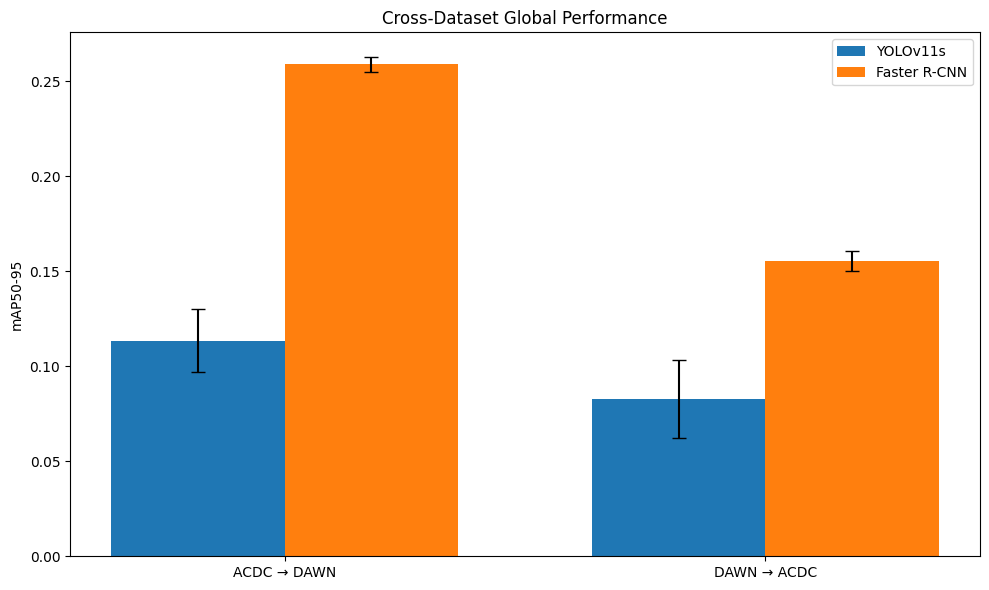

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/figures/cross_dataset_global_map50_95.png


In [ ]:
plot_df = global_summary.dropna(subset=["mAP50_95_mean"]).copy()

directions = list(plot_df["transfer_direction"].dropna().unique())
models = ["YOLOv11s", "Faster R-CNN"]

x = np.arange(len(directions))
width = 0.36

plt.figure(figsize=(10, 6))

for index, model in enumerate(models):
    model_df = (
        plot_df[plot_df["model"] == model]
        .set_index("transfer_direction")
        .reindex(directions)
    )

    positions = x + (index - 0.5) * width

    plt.bar(
        positions,
        model_df["mAP50_95_mean"],
        width,
        yerr=model_df["mAP50_95_std"],
        capsize=5,
        label=model,
    )

plt.xticks(x, directions)
plt.ylabel("mAP50-95")
plt.title("Cross-Dataset Global Performance")
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "cross_dataset_global_map50_95.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)


# Global mAP50 plot

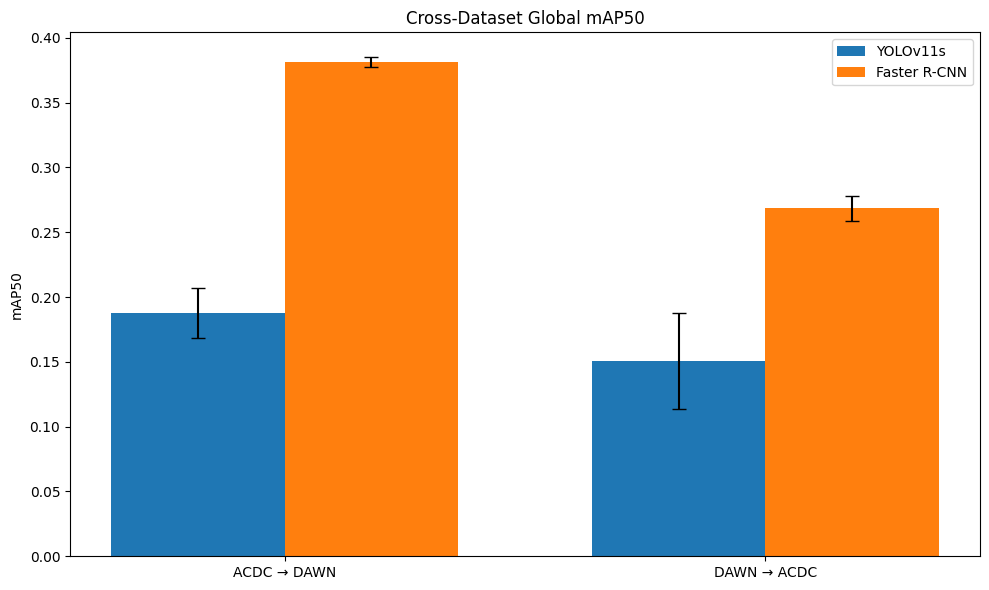

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/figures/cross_dataset_global_map50.png


In [ ]:
plot_df = global_summary.dropna(subset=["mAP50_mean"]).copy()

directions = list(plot_df["transfer_direction"].dropna().unique())
models = ["YOLOv11s", "Faster R-CNN"]

x = np.arange(len(directions))
width = 0.36

plt.figure(figsize=(10, 6))

for index, model in enumerate(models):
    model_df = (
        plot_df[plot_df["model"] == model]
        .set_index("transfer_direction")
        .reindex(directions)
    )

    positions = x + (index - 0.5) * width

    plt.bar(
        positions,
        model_df["mAP50_mean"],
        width,
        yerr=model_df["mAP50_std"],
        capsize=5,
        label=model,
    )

plt.xticks(x, directions)
plt.ylabel("mAP50")
plt.title("Cross-Dataset Global mAP50")
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "cross_dataset_global_map50.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)


# Weather-specific cross-dataset summary



In [ ]:
weather_cross_df = cross_df[
    cross_df["condition"].isin(["fog", "rain", "snow"])
].copy()

weather_summary = (
    weather_cross_df
    .groupby(
        [
            "transfer_direction",
            "model",
            "condition",
        ],
        dropna=False,
    )
    .agg(
        seeds=("seed", "nunique"),
        mAP50_95_mean=("mAP50-95", "mean"),
        mAP50_95_std=("mAP50-95", "std"),
        mAP50_mean=("mAP50", "mean"),
        mAP50_std=("mAP50", "std"),
        Precision_mean=("Precision", "mean"),
        Recall_mean=("Recall", "mean"),
        F1_mean=("F1-score", "mean"),
    )
    .reset_index()
)

display(weather_summary.round(4))


,transfer_direction,model,condition,seeds,mAP50_95_mean,mAP50_95_std,mAP50_mean,mAP50_std,Precision_mean,Recall_mean,F1_mean
0,ACDC → DAWN,Faster R-CNN,fog,3,0.2437,0.0079,0.3531,0.0121,NaN,NaN,NaN
1,ACDC → DAWN,Faster R-CNN,rain,3,0.2372,0.0207,0.3762,0.0179,NaN,NaN,NaN
2,ACDC → DAWN,Faster R-CNN,snow,3,0.3120,0.0285,0.4645,0.0431,NaN,NaN,NaN
3,ACDC → DAWN,YOLOv11s,fog,3,0.0873,0.0052,0.1511,0.0168,0.3985,0.1430,0.2034
4,ACDC → DAWN,YOLOv11s,rain,3,0.1692,0.0497,0.2621,0.0352,0.7338,0.2481,0.3649
5,ACDC → DAWN,YOLOv11s,snow,3,0.1844,0.0167,0.2912,0.0115,0.5812,0.2460,0.3429
6,DAWN → ACDC,Faster R-CNN,fog,3,0.2131,0.0027,0.3564,0.0191,NaN,NaN,NaN
7,DAWN → ACDC,Faster R-CNN,rain,3,0.1427,0.0077,0.2418,0.0101,NaN,NaN,NaN
8,DAWN → ACDC,Faster R-CNN,snow,3,0.1765,0.0025,0.3061,0.0066,NaN,NaN,NaN
9,DAWN → ACDC,YOLOv11s,fog,3,0.0935,0.0246,0.1707,0.0438,0.5301,0.2179,0.3028


# Weather plots

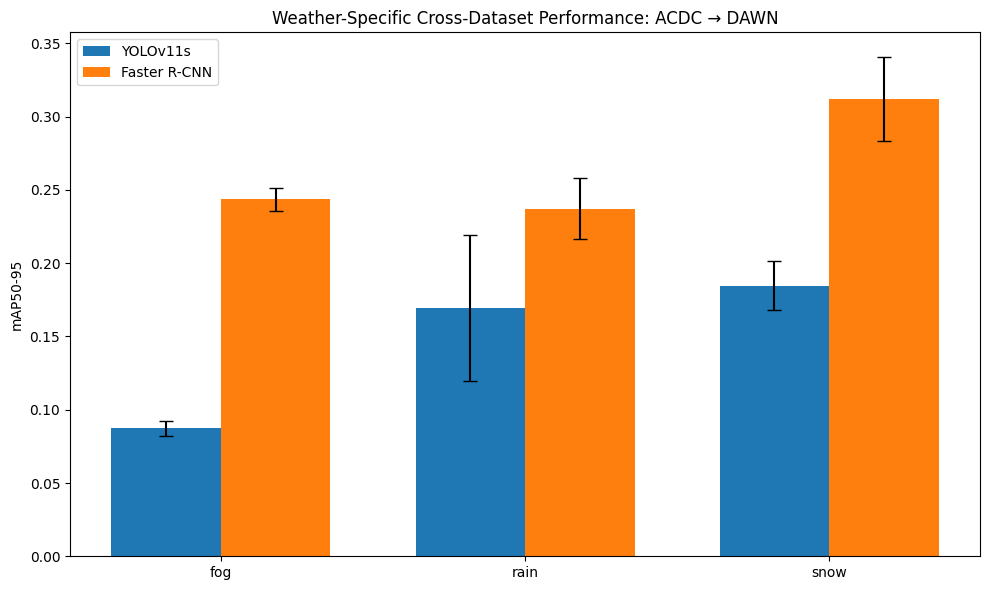

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/figures/acdc_to_dawn_weather_map50_95.png


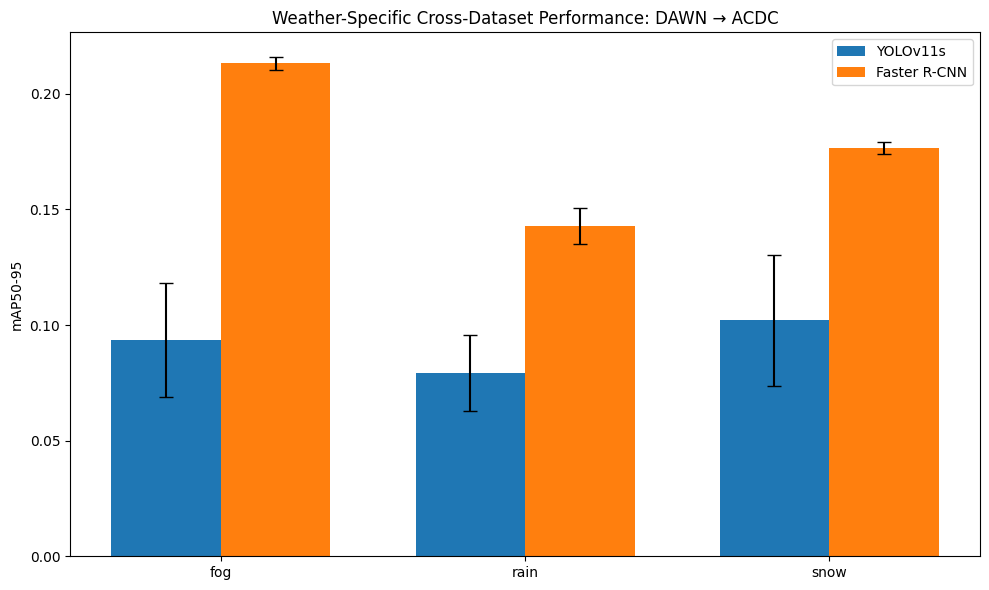

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/figures/dawn_to_acdc_weather_map50_95.png


In [ ]:
for direction in sorted(weather_summary["transfer_direction"].dropna().unique()):
    direction_df = weather_summary[
        weather_summary["transfer_direction"] == direction
    ].copy()

    conditions = ["fog", "rain", "snow"]
    models = ["YOLOv11s", "Faster R-CNN"]

    x = np.arange(len(conditions))
    width = 0.36

    plt.figure(figsize=(10, 6))

    for index, model in enumerate(models):
        model_df = (
            direction_df[direction_df["model"] == model]
            .set_index("condition")
            .reindex(conditions)
        )

        positions = x + (index - 0.5) * width

        plt.bar(
            positions,
            model_df["mAP50_95_mean"],
            width,
            yerr=model_df["mAP50_95_std"],
            capsize=5,
            label=model,
        )

    plt.xticks(x, conditions)
    plt.ylabel("mAP50-95")
    plt.title(f"Weather-Specific Cross-Dataset Performance: {direction}")
    plt.legend()
    plt.tight_layout()

    safe_direction = direction.replace(" → ", "_to_").lower()
    figure_path = FIGURES_DIR / f"{safe_direction}_weather_map50_95.png"

    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", figure_path)


# Weather ranking

In [ ]:
weather_ranking = weather_summary.copy()

weather_ranking["rank_within_direction_and_model"] = (
    weather_ranking
    .groupby(["transfer_direction", "model"])["mAP50_95_mean"]
    .rank(method="dense", ascending=False)
)

weather_ranking = weather_ranking.sort_values(
    [
        "transfer_direction",
        "model",
        "rank_within_direction_and_model",
    ]
)

display(weather_ranking.round(4))


,transfer_direction,model,condition,seeds,mAP50_95_mean,mAP50_95_std,mAP50_mean,mAP50_std,Precision_mean,Recall_mean,F1_mean,rank_within_direction_and_model
2,ACDC → DAWN,Faster R-CNN,snow,3,0.3120,0.0285,0.4645,0.0431,NaN,NaN,NaN,1.0000
0,ACDC → DAWN,Faster R-CNN,fog,3,0.2437,0.0079,0.3531,0.0121,NaN,NaN,NaN,2.0000
1,ACDC → DAWN,Faster R-CNN,rain,3,0.2372,0.0207,0.3762,0.0179,NaN,NaN,NaN,3.0000
5,ACDC → DAWN,YOLOv11s,snow,3,0.1844,0.0167,0.2912,0.0115,0.5812,0.2460,0.3429,1.0000
4,ACDC → DAWN,YOLOv11s,rain,3,0.1692,0.0497,0.2621,0.0352,0.7338,0.2481,0.3649,2.0000
3,ACDC → DAWN,YOLOv11s,fog,3,0.0873,0.0052,0.1511,0.0168,0.3985,0.1430,0.2034,3.0000
6,DAWN → ACDC,Faster R-CNN,fog,3,0.2131,0.0027,0.3564,0.0191,NaN,NaN,NaN,1.0000
8,DAWN → ACDC,Faster R-CNN,snow,3,0.1765,0.0025,0.3061,0.0066,NaN,NaN,NaN,2.0000
7,DAWN → ACDC,Faster R-CNN,rain,3,0.1427,0.0077,0.2418,0.0101,NaN,NaN,NaN,3.0000
11,DAWN → ACDC,YOLOv11s,snow,3,0.1020,0.0283,0.1856,0.0508,0.5922,0.1859,0.2801,1.0000


# In-domain versus cross-dataset drop

In [ ]:
in_domain_df = results_df[
    (results_df["experiment"] == "in_domain")
    & (results_df["condition"] == "global")
].copy()

# Prefer seed 42 for the in-domain baseline because that is the available
# common baseline in the project results.
in_domain_seed42_df = in_domain_df[
    in_domain_df["seed"] == 42
].copy()

display(
    in_domain_seed42_df[
        [
            "dataset",
            "model",
            "seed",
            "mAP50-95",
            "mAP50",
            "Precision",
            "Recall",
            "FPS",
        ]
    ]
)


,dataset,model,seed,mAP50-95,mAP50,Precision,Recall,FPS
4,ACDC,Faster R-CNN,42,0.4128,0.5963,NaN,NaN,16.1030
28,DAWN,Faster R-CNN,42,0.4679,0.7095,NaN,NaN,20.5414
49,ACDC,YOLOv11s,42,0.3329,0.5212,0.7650,0.4413,84.5323


In [ ]:
cross_vs_indomain_records = []

for _, cross_row in global_summary.iterrows():
    source_dataset = (
        "ACDC"
        if cross_row["transfer_direction"] == "ACDC → DAWN"
        else "DAWN"
    )

    baseline_rows = in_domain_seed42_df[
        (in_domain_seed42_df["dataset"] == source_dataset)
        & (in_domain_seed42_df["model"] == cross_row["model"])
    ]

    if baseline_rows.empty:
        continue

    baseline_row = baseline_rows.iloc[0]
    baseline_map = baseline_row["mAP50-95"]
    cross_map = cross_row["mAP50_95_mean"]

    absolute_drop = baseline_map - cross_map

    relative_drop_percent = (
        absolute_drop / baseline_map * 100
        if pd.notna(baseline_map) and baseline_map != 0
        else np.nan
    )

    cross_vs_indomain_records.append({
        "transfer_direction": cross_row["transfer_direction"],
        "model": cross_row["model"],
        "source_in_domain_mAP50-95": baseline_map,
        "cross_dataset_mAP50-95_mean": cross_map,
        "absolute_drop": absolute_drop,
        "relative_drop_percent": relative_drop_percent,
    })

accuracy_drop_df = pd.DataFrame(cross_vs_indomain_records)

display(accuracy_drop_df.round(4))


,transfer_direction,model,source_in_domain_mAP50-95,cross_dataset_mAP50-95_mean,absolute_drop,relative_drop_percent
0,ACDC → DAWN,Faster R-CNN,0.4128,0.2589,0.1539,37.2775
1,ACDC → DAWN,YOLOv11s,0.3329,0.1135,0.2195,65.9170
2,DAWN → ACDC,Faster R-CNN,0.4679,0.1555,0.3124,66.7574


# Accuracy-drop plot

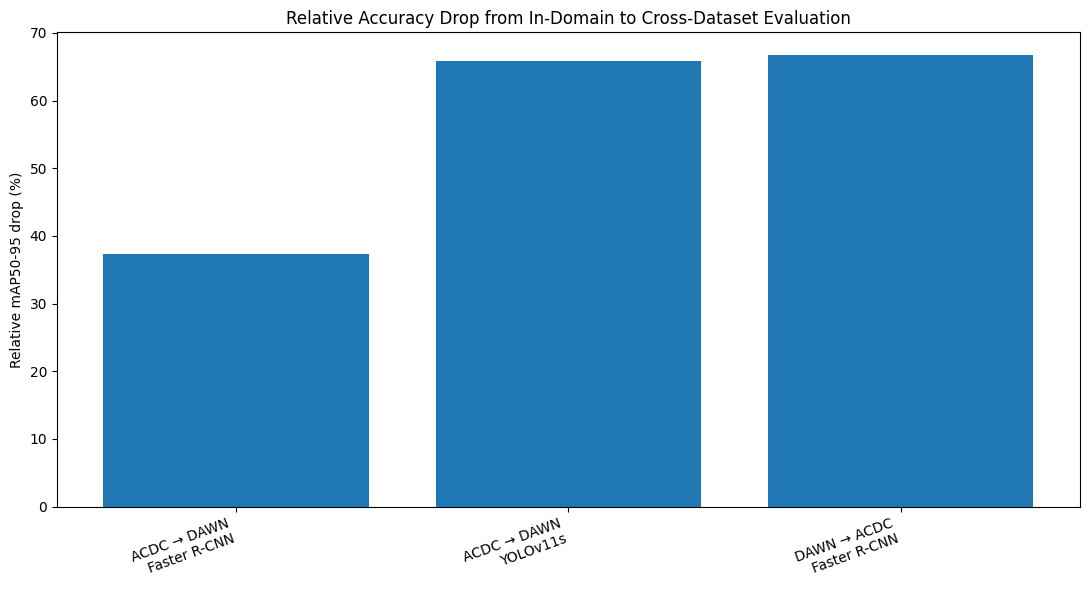

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/figures/relative_cross_dataset_accuracy_drop.png


In [ ]:
if not accuracy_drop_df.empty:
    plot_df = accuracy_drop_df.copy()

    labels = (
        plot_df["transfer_direction"]
        + "\n"
        + plot_df["model"]
    )

    plt.figure(figsize=(11, 6))
    plt.bar(labels, plot_df["relative_drop_percent"])
    plt.ylabel("Relative mAP50-95 drop (%)")
    plt.title("Relative Accuracy Drop from In-Domain to Cross-Dataset Evaluation")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    figure_path = FIGURES_DIR / "relative_cross_dataset_accuracy_drop.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", figure_path)
else:
    print("Accuracy-drop table is empty because no matching in-domain baseline was found.")


# Direct model comparison

In [ ]:
model_comparison = (
    global_summary
    .pivot(
        index="transfer_direction",
        columns="model",
        values="mAP50_95_mean",
    )
    .reset_index()
)

if {"YOLOv11s", "Faster R-CNN"}.issubset(model_comparison.columns):
    model_comparison["Faster_R-CNN_minus_YOLO"] = (
        model_comparison["Faster R-CNN"]
        - model_comparison["YOLOv11s"]
    )

display(model_comparison.round(4))


model,transfer_direction,Faster R-CNN,YOLOv11s,Faster_R-CNN_minus_YOLO
0,ACDC → DAWN,0.2589,0.1135,0.1454
1,DAWN → ACDC,0.1555,0.0828,0.0727


# Seed stability

In [ ]:
seed_stability = (
    global_cross_df
    .groupby(["transfer_direction", "model"])
    .agg(
        mean_mAP50_95=("mAP50-95", "mean"),
        std_mAP50_95=("mAP50-95", "std"),
        min_mAP50_95=("mAP50-95", "min"),
        max_mAP50_95=("mAP50-95", "max"),
        range_mAP50_95=("mAP50-95", lambda values: values.max() - values.min()),
    )
    .reset_index()
)

display(seed_stability.round(4))


,transfer_direction,model,mean_mAP50_95,std_mAP50_95,min_mAP50_95,max_mAP50_95,range_mAP50_95
0,ACDC → DAWN,Faster R-CNN,0.2589,0.0038,0.2546,0.2616,0.0070
1,ACDC → DAWN,YOLOv11s,0.1135,0.0167,0.0957,0.1287,0.0331
2,DAWN → ACDC,Faster R-CNN,0.1555,0.0054,0.1506,0.1612,0.0106
3,DAWN → ACDC,YOLOv11s,0.0828,0.0206,0.0709,0.1066,0.0357


# Interpretation

In [ ]:
interpretation_lines = []

if not global_summary.empty:
    best_global_row = global_summary.loc[
        global_summary["mAP50_95_mean"].idxmax()
    ]

    interpretation_lines.append(
        "The highest mean global cross-dataset mAP50-95 was obtained by "
        f'{best_global_row["model"]} for {best_global_row["transfer_direction"]} '
        f'({best_global_row["mAP50_95_mean"]:.4f} ± '
        f'{best_global_row["mAP50_95_std"]:.4f}).'
    )

if not model_comparison.empty and "Faster_R-CNN_minus_YOLO" in model_comparison.columns:
    for _, row in model_comparison.iterrows():
        difference = row["Faster_R-CNN_minus_YOLO"]

        if pd.isna(difference):
            continue

        better_model = "Faster R-CNN" if difference > 0 else "YOLOv11s"

        interpretation_lines.append(
            f'For {row["transfer_direction"]}, {better_model} achieved the '
            f'higher mean global mAP50-95, with an absolute difference of '
            f'{abs(difference):.4f}.'
        )

if not weather_summary.empty:
    for (direction, model), group in weather_summary.groupby(
        ["transfer_direction", "model"]
    ):
        valid_group = group.dropna(subset=["mAP50_95_mean"])

        if valid_group.empty:
            continue

        best_weather = valid_group.loc[
            valid_group["mAP50_95_mean"].idxmax()
        ]

        worst_weather = valid_group.loc[
            valid_group["mAP50_95_mean"].idxmin()
        ]

        interpretation_lines.append(
            f'For {model} under {direction}, '
            f'{best_weather["condition"]} produced the strongest mean '
            f'mAP50-95 ({best_weather["mAP50_95_mean"]:.4f}), while '
            f'{worst_weather["condition"]} produced the weakest '
            f'({worst_weather["mAP50_95_mean"]:.4f}).'
        )

if not accuracy_drop_df.empty:
    largest_drop_row = accuracy_drop_df.loc[
        accuracy_drop_df["relative_drop_percent"].idxmax()
    ]

    interpretation_lines.append(
        "The largest relative deterioration from the source in-domain "
        f'baseline occurred for {largest_drop_row["model"]} under '
        f'{largest_drop_row["transfer_direction"]}, with a '
        f'{largest_drop_row["relative_drop_percent"]:.2f}% reduction in '
        "mAP50-95."
    )

interpretation_text = "\n".join(
    f"- {line}" for line in interpretation_lines
)

print(interpretation_text)


- The highest mean global cross-dataset mAP50-95 was obtained by Faster R-CNN for ACDC → DAWN (0.2589 ± 0.0038).
- For ACDC → DAWN, Faster R-CNN achieved the higher mean global mAP50-95, with an absolute difference of 0.1454.
- For DAWN → ACDC, Faster R-CNN achieved the higher mean global mAP50-95, with an absolute difference of 0.0727.
- For Faster R-CNN under ACDC → DAWN, snow produced the strongest mean mAP50-95 (0.3120), while rain produced the weakest (0.2372).
- For YOLOv11s under ACDC → DAWN, snow produced the strongest mean mAP50-95 (0.1844), while fog produced the weakest (0.0873).
- For Faster R-CNN under DAWN → ACDC, fog produced the strongest mean mAP50-95 (0.2131), while rain produced the weakest (0.1427).
- For YOLOv11s under DAWN → ACDC, snow produced the strongest mean mAP50-95 (0.1020), while rain produced the weakest (0.0793).
- The largest relative deterioration from the source in-domain baseline occurred for Faster R-CNN under DAWN → ACDC, with a 66.76% reduction in

In [ ]:
results_df.groupby(
    ["dataset", "experiment", "model"]
).size()

dataset  experiment  model       
ACDC     dawn_>acdc  Faster R-CNN    12
                     YOLOv11s        12
         in_domain   Faster R-CNN     8
                     YOLOv11s        14
DAWN     acdc_>dawn  Faster R-CNN    12
                     YOLOv11s        12
         in_domain   Faster R-CNN    12
                     YOLOv11s         2
dtype: int64

In [ ]:
results_df[
    ["dataset", "experiment", "model", "seed"]
].sort_values(
    ["dataset", "experiment", "model", "seed"]
)

,dataset,experiment,model,seed
36,ACDC,dawn_>acdc,Faster R-CNN,42
37,ACDC,dawn_>acdc,Faster R-CNN,42
38,ACDC,dawn_>acdc,Faster R-CNN,42
39,ACDC,dawn_>acdc,Faster R-CNN,42
32,ACDC,dawn_>acdc,Faster R-CNN,123
33,ACDC,dawn_>acdc,Faster R-CNN,123
34,ACDC,dawn_>acdc,Faster R-CNN,123
35,ACDC,dawn_>acdc,Faster R-CNN,123
40,ACDC,dawn_>acdc,Faster R-CNN,456
41,ACDC,dawn_>acdc,Faster R-CNN,456


# **Export resuts and interpretation**

In [ ]:
results_df.to_csv(
    TABLES_DIR / "all_standardised_results.csv",
    index=False,
)

cross_df.to_csv(
    TABLES_DIR / "cross_dataset_all_seeds.csv",
    index=False,
)

coverage_table.to_csv(
    TABLES_DIR / "cross_dataset_coverage.csv",
    index=False,
)

global_summary.to_csv(
    TABLES_DIR / "cross_dataset_global_summary_mean_std.csv",
    index=False,
)

publication_global_table.to_csv(
    TABLES_DIR / "cross_dataset_global_publication_table.csv",
    index=False,
)

weather_summary.to_csv(
    TABLES_DIR / "cross_dataset_weather_summary_mean_std.csv",
    index=False,
)

weather_ranking.to_csv(
    TABLES_DIR / "cross_dataset_weather_ranking.csv",
    index=False,
)

seed_stability.to_csv(
    TABLES_DIR / "cross_dataset_seed_stability.csv",
    index=False,
)

model_comparison.to_csv(
    TABLES_DIR / "cross_dataset_model_comparison.csv",
    index=False,
)

if not accuracy_drop_df.empty:
    accuracy_drop_df.to_csv(
        TABLES_DIR / "cross_dataset_accuracy_drop.csv",
        index=False,
    )

with open(
    OUTPUT_DIR / "automatic_interpretation.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(interpretation_text)

print("Exports completed.")
print("Tables:", TABLES_DIR)
print("Figures:", FIGURES_DIR)
print("Interpretation:", OUTPUT_DIR / "automatic_interpretation.txt")


Exports completed.
Tables: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/tables
Figures: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/figures
Interpretation: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/automatic_interpretation.txt
